# DHBW Machine Learning: R2-D2

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree


## Buisiness & Data Understanding

### Überblick über den Datensatz

In [56]:
data = pd.read_csv("SeoulBikeData.csv")
data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## Data Preparation

### Umgang mit fehlenden Werten

In diesem Datensatz sind keine fehlende Werte vorhanden.

In [57]:
data.isna().values.any()

np.False_

### Codierung von Variablen
Date wird entfernt, da relevante Informationen durch `Temperatur`,`Season` und `Holiday` gegeben sind.

`Season`,`Holiday` und `Functioning Day` werden mit Dummy Variablen initialisiert.

In [58]:
data = data.drop(columns="Date")

In [59]:
data_encoded = pd.get_dummies(
    data=data, columns=["Seasons", "Holiday", "Functioning Day"], drop_first=True
)

### Zielvariable
Die Zielvariable soll die ausgeliehenen Fahrräder an einem gegeben Tag sein.

In [60]:
target = "Rented Bike Count"
X = data_encoded.drop(columns=target)
y = data_encoded[target]

### Aufteilung in Trainings- und Testdaten


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modeling
### Linear Regression

In [62]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
lr_model = LinearRegression()
cv_scores = cross_val_score(
    lr_model, X_train, y_train, cv=kfold, scoring="neg_mean_squared_error"
)
cv_error = -cv_scores.mean()
np.sqrt(cv_error)

np.float64(431.62529986615147)

### Polynomiale Regression


In [63]:
polypipe = Pipeline([
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear_regression", LinearRegression())
])


In [64]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    polypipe, X_train, y_train, cv=kfold, scoring="neg_mean_squared_error"
)
cv_error = -cv_scores.mean()
np.sqrt(cv_error)

np.float64(352.7958884382892)

### Regression Tree

In [65]:
tree = DecisionTreeRegressor(
    random_state = 42,
    max_depth=3
) 

In [66]:
tree.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

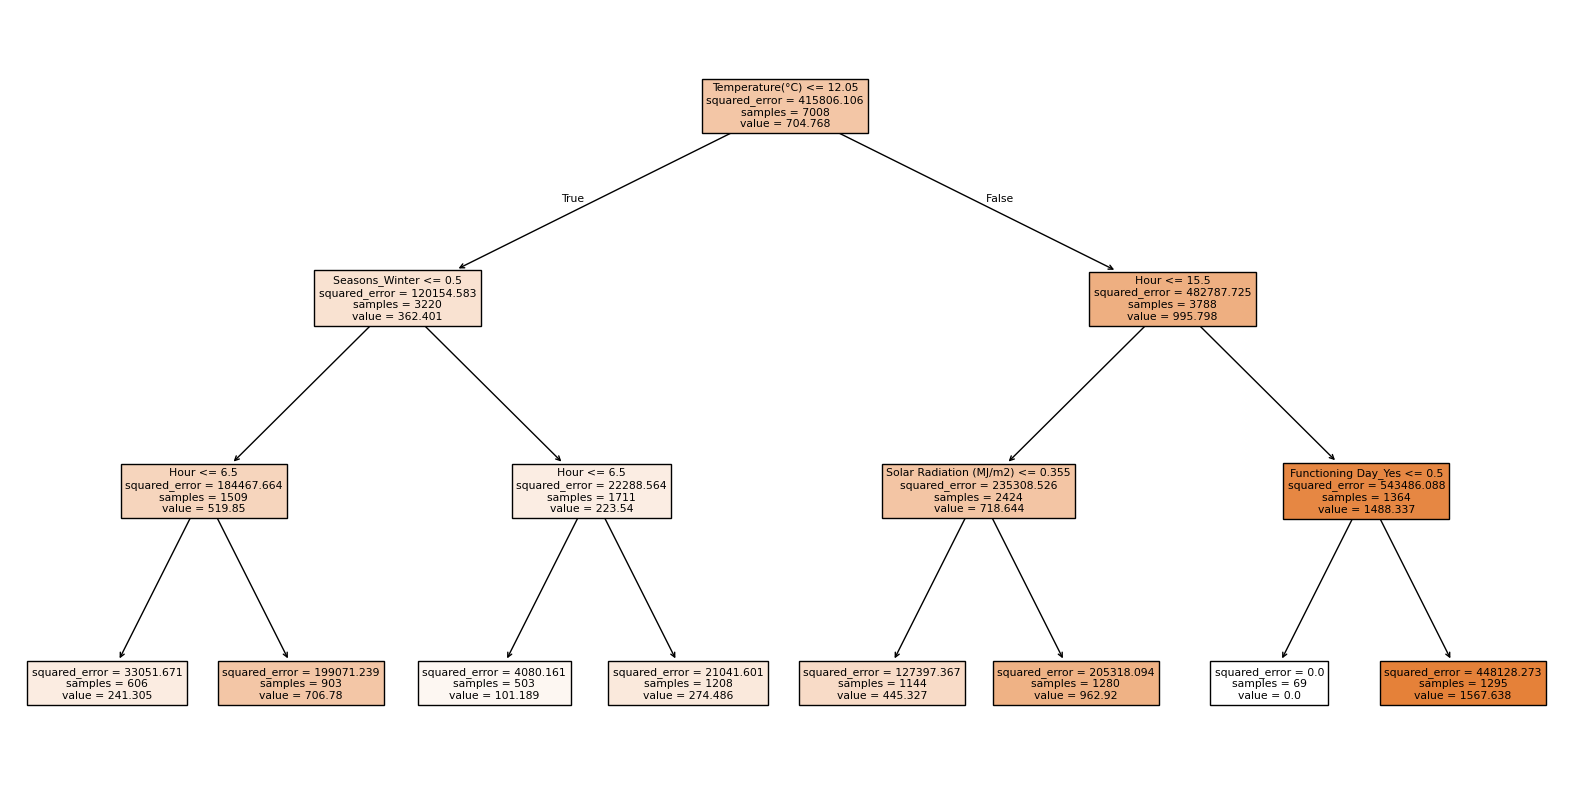

In [67]:
plt.figure(figsize=(20, 10))
plot_tree(tree, filled=True, feature_names=X.columns)
plt.show()

#### Pruning

In [68]:
kfold=KFold(
    n_splits=10,
    shuffle=True,
    random_state=42

)


In [69]:
fulltree = DecisionTreeRegressor(
    random_state=42
)
path = fulltree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

In [ ]:
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid={"ccp_alpha": ccp_alphas},
    cv=kfold,
    scoring="neg_mean_squared_error"
)
grid_search.fit(X_train, y_train)